# ssqueezepy 演示：STFT & CWT

本 notebook 演示 `ssqueezepy` 库的两种时频分析方法：

- **STFT**（短时傅里叶变换）— `ssqueezepy.stft` / `ssqueezepy.istft`
- **CWT**（连续小波变换）— `ssqueezepy.cwt` / `ssqueezepy.icwt`

生成一个包含线性调频（chirp）和多频分量的测试信号，分别用 STFT 和 CWT 做时频分析并对比效果。

In [8]:
# 安装 ssqueezepy（首次运行需要）
# !pip install ssqueezepy numpy matplotlib

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from ssqueezepy import stft, istft, cwt, icwt, ssq_stft, ssq_cwt
from ssqueezepy.visuals import plot, imshow

# matplotlib 中文字体配置
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

print("ssqueezepy 导入成功")

ssqueezepy 导入成功


## 生成测试信号

合成一个包含以下分量的测试信号：
- 线性调频（chirp）：频率从 10 Hz 扫到 80 Hz
- 固定单频：60 Hz 正弦波
- 高频突发：120 Hz 的短促脉冲

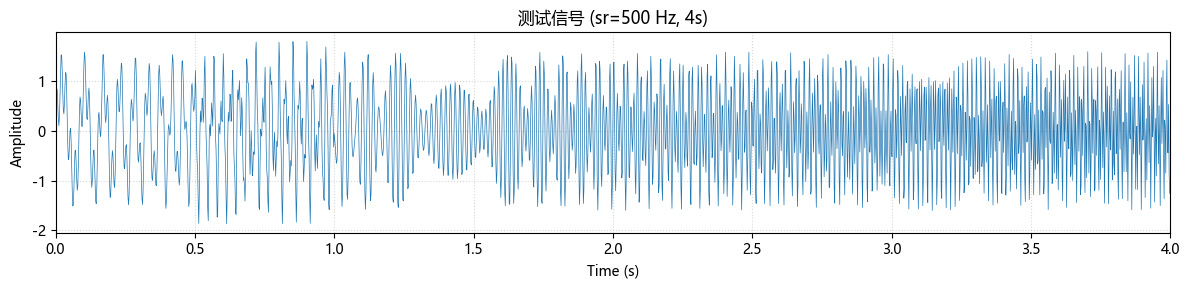

In [10]:
# 参数设置
sr = 500        # 采样率 (Hz)
T = 4.0         # 时长 (秒)
t = np.linspace(0, T, int(sr * T), endpoint=False)

# 信号 1：线性调频 10→80 Hz
f0, f1 = 10, 80
chirp = np.sin(2 * np.pi * np.linspace(f0, f1, len(t)) * t)

# 信号 2：固定 60 Hz
tone60 = 0.6 * np.sin(2 * np.pi * 60 * t)

# 信号 3：120 Hz 突发（0.5s~1.0s）
burst = np.zeros_like(t)
mask = (t >= 0.5) & (t < 1.0)
burst[mask] = 0.4 * np.sin(2 * np.pi * 120 * t[mask])

# 混合信号
x = chirp + tone60 + burst

# 可视化时域波形
plt.figure(figsize=(12, 3))
plt.plot(t, x, lw=0.5)
plt.xlim(0, T)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"测试信号 (sr={sr} Hz, {T:.0f}s)")
plt.grid(ls=':', alpha=0.5)
plt.tight_layout()
plt.show()

## CWT（连续小波变换）

使用 `ssqueezepy.cwt` 计算时频谱。CWT 使用 Morlet 小波，纵轴为尺度换算得到的频率。

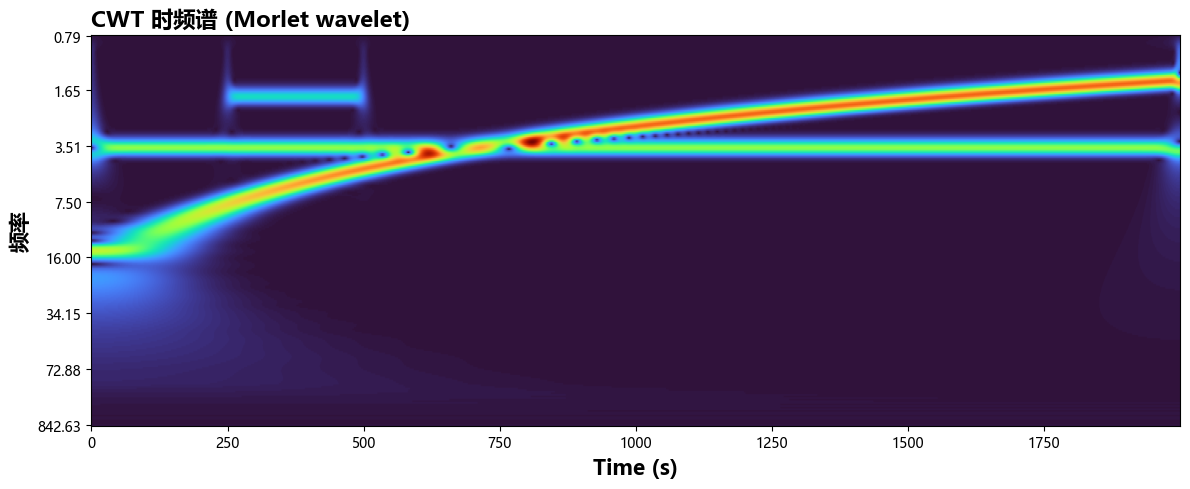

CWT 输出形状: (245, 2000)
尺度数: 245


In [11]:
# CWT 时频分析
Wx_cwt, scales = cwt(x, fs=sr)

# 可视化 CWT 时频谱
plt.figure(figsize=(12, 5))
imshow(Wx_cwt, yticks=scales, abs=1, show=0,
       title="CWT 时频谱 (Morlet wavelet)",
       xlabel="Time (s)", ylabel="频率")
plt.tight_layout()
plt.show()

print(f"CWT 输出形状: {Wx_cwt.shape}")
print(f"尺度数: {len(scales)}")

## STFT（短时傅里叶变换）

使用 `ssqueezepy.stft` 计算时频谱。STFT 使用固定窗口长度，在整个时频平面有均匀的分辨率。

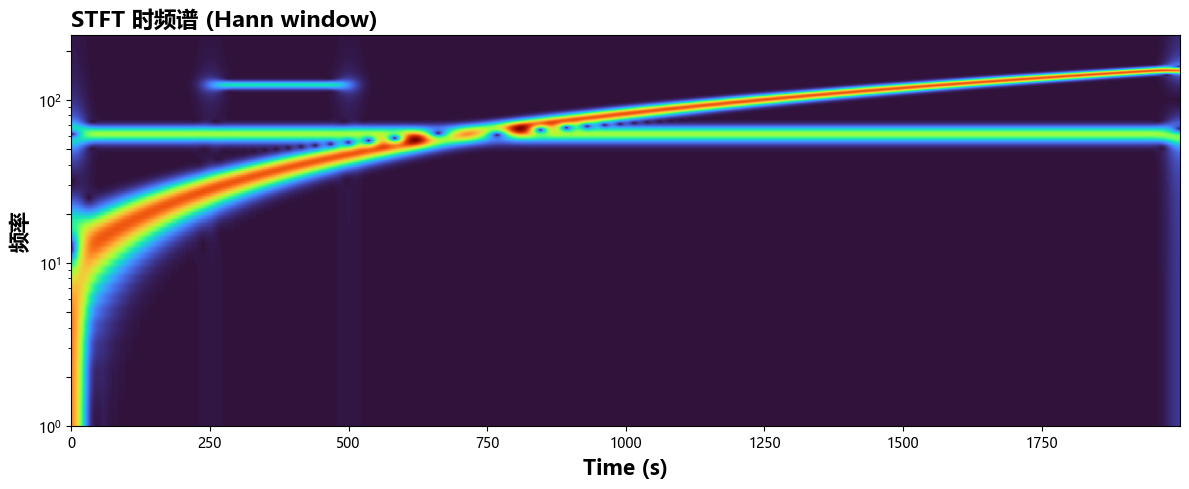

STFT 输出形状: (257, 2000)


In [12]:
# STFT 时频分析
Sx_stft = stft(x, fs=sr)

# STFT 频率轴（0 ~ sr/2 Hz）
freqs_stft = np.linspace(0, sr / 2, Sx_stft.shape[0])

# 可视化 STFT 时频谱
plt.figure(figsize=(12, 5))
imshow(Sx_stft, yticks=freqs_stft, abs=1, origin='lower', show=0,
       title="STFT 时频谱 (Hann window)",
       xlabel="Time (s)", ylabel="频率")
ax = plt.gca()
ax.set_yscale('log')
ax.set_ylim(1, sr / 2)
ax.set_yticks([1, 2, 5, 10, 20, 50, 100, 200])
plt.tight_layout()
plt.show()

print(f"STFT 输出形状: {Sx_stft.shape}")

## SST（同步压缩变换）对比

使用 `ssqueezepy` 提供的 `ssq_cwt` 和 `ssq_stft` 进行同步压缩，使时频谱更锐利、更易读。

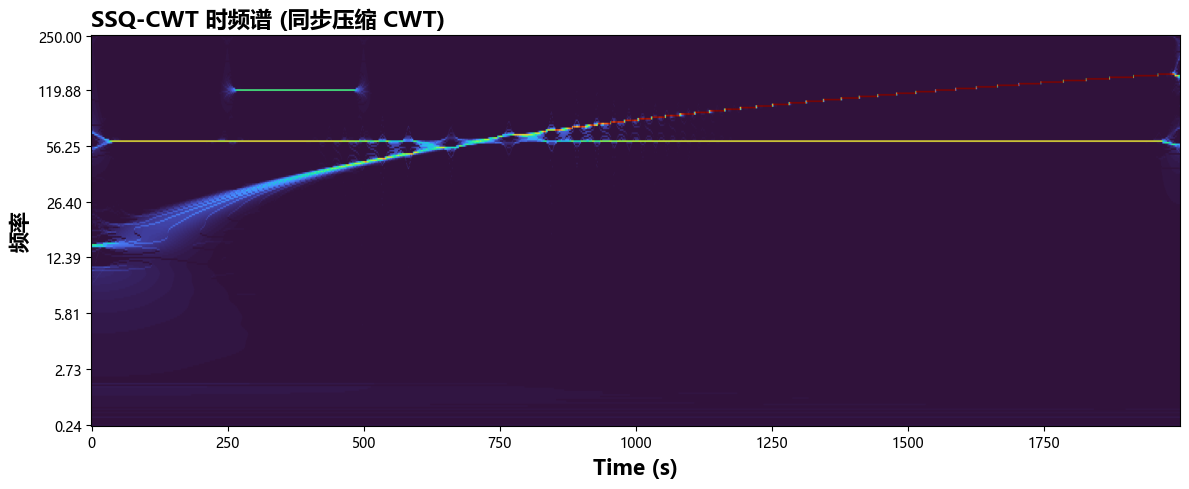

SSQ-CWT 输出形状: (245, 2000)


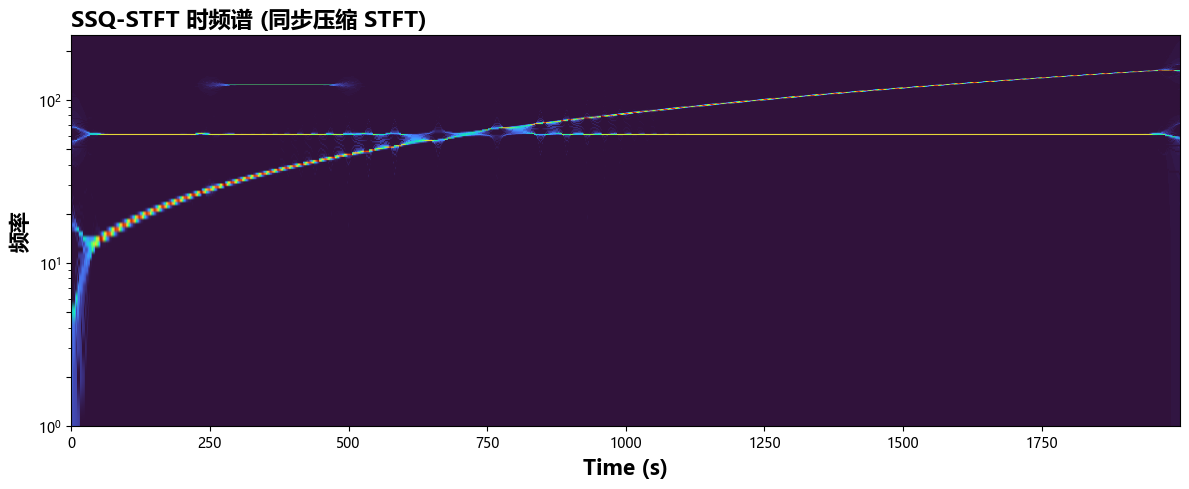

SSQ-STFT 输出形状: (257, 2000)


In [13]:
# ---- SSQ_CWT ----
Tx_cwt, _, fs_cwt, _ = ssq_cwt(x, fs=sr)

plt.figure(figsize=(12, 5))
imshow(Tx_cwt, yticks=fs_cwt, abs=1, show=0,
       title="SSQ-CWT 时频谱 (同步压缩 CWT)",
       xlabel="Time (s)", ylabel="频率")
plt.tight_layout()
plt.show()

print(f"SSQ-CWT 输出形状: {Tx_cwt.shape}")

# ---- SSQ_STFT ----
Tx_stft, _, fs_stft, _ = ssq_stft(x, fs=sr)

plt.figure(figsize=(12, 5))
imshow(Tx_stft, yticks=fs_stft, abs=1, origin='lower', show=0,
       title="SSQ-STFT 时频谱 (同步压缩 STFT)",
       xlabel="Time (s)", ylabel="频率")
ax = plt.gca()
ax.set_yscale('log')
ax.set_ylim(1, sr / 2)
ax.set_yticks([1, 2, 5, 10, 20, 50, 100, 200])
plt.tight_layout()
plt.show()

print(f"SSQ-STFT 输出形状: {Tx_stft.shape}")

## 四图对比总结

将 CWT、STFT、SSQ-CWT、SSQ-STFT 四个时频谱放在一起直观对比。

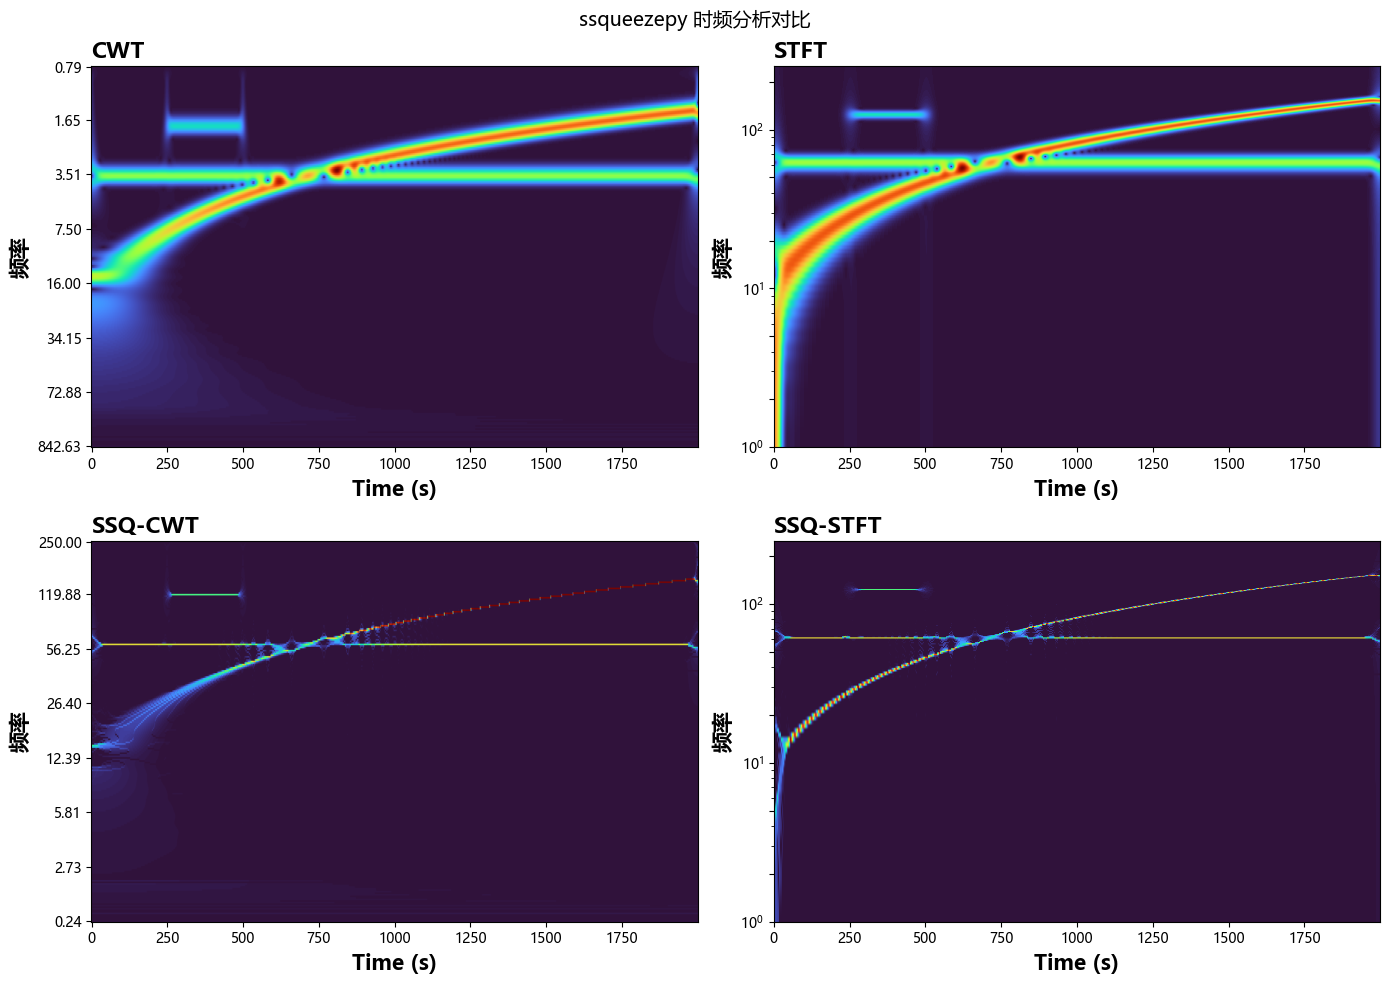

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# CWT
imshow(Wx_cwt, yticks=scales, abs=1, ax=axes[0, 0], show=0,
       title="CWT", xlabel="Time (s)", ylabel="频率")

# STFT
imshow(Sx_stft, yticks=freqs_stft, abs=1, ax=axes[0, 1], show=0, origin='lower',
       title="STFT", xlabel="Time (s)", ylabel="频率")
axes[0, 1].set_yscale('log')
axes[0, 1].set_ylim(1, sr / 2)
axes[0, 1].set_yticks([1, 2, 5, 10, 20, 50, 100, 200])

# SSQ-CWT
imshow(Tx_cwt, yticks=fs_cwt, abs=1, ax=axes[1, 0], show=0,
       title="SSQ-CWT", xlabel="Time (s)", ylabel="频率")

# SSQ-STFT
imshow(Tx_stft, yticks=fs_stft, abs=1, ax=axes[1, 1], show=0, origin='lower',
       title="SSQ-STFT", xlabel="Time (s)", ylabel="频率")
axes[1, 1].set_yscale('log')
axes[1, 1].set_ylim(1, sr / 2)
axes[1, 1].set_yticks([1, 2, 5, 10, 20, 50, 100, 200])

plt.suptitle("ssqueezepy 时频分析对比", fontsize=14)
plt.tight_layout()
plt.show()

## 1 Hz 纯音测试

用四种方法分析一个 1 Hz 的纯音信号，观察 CWT 在极低频下的表现。

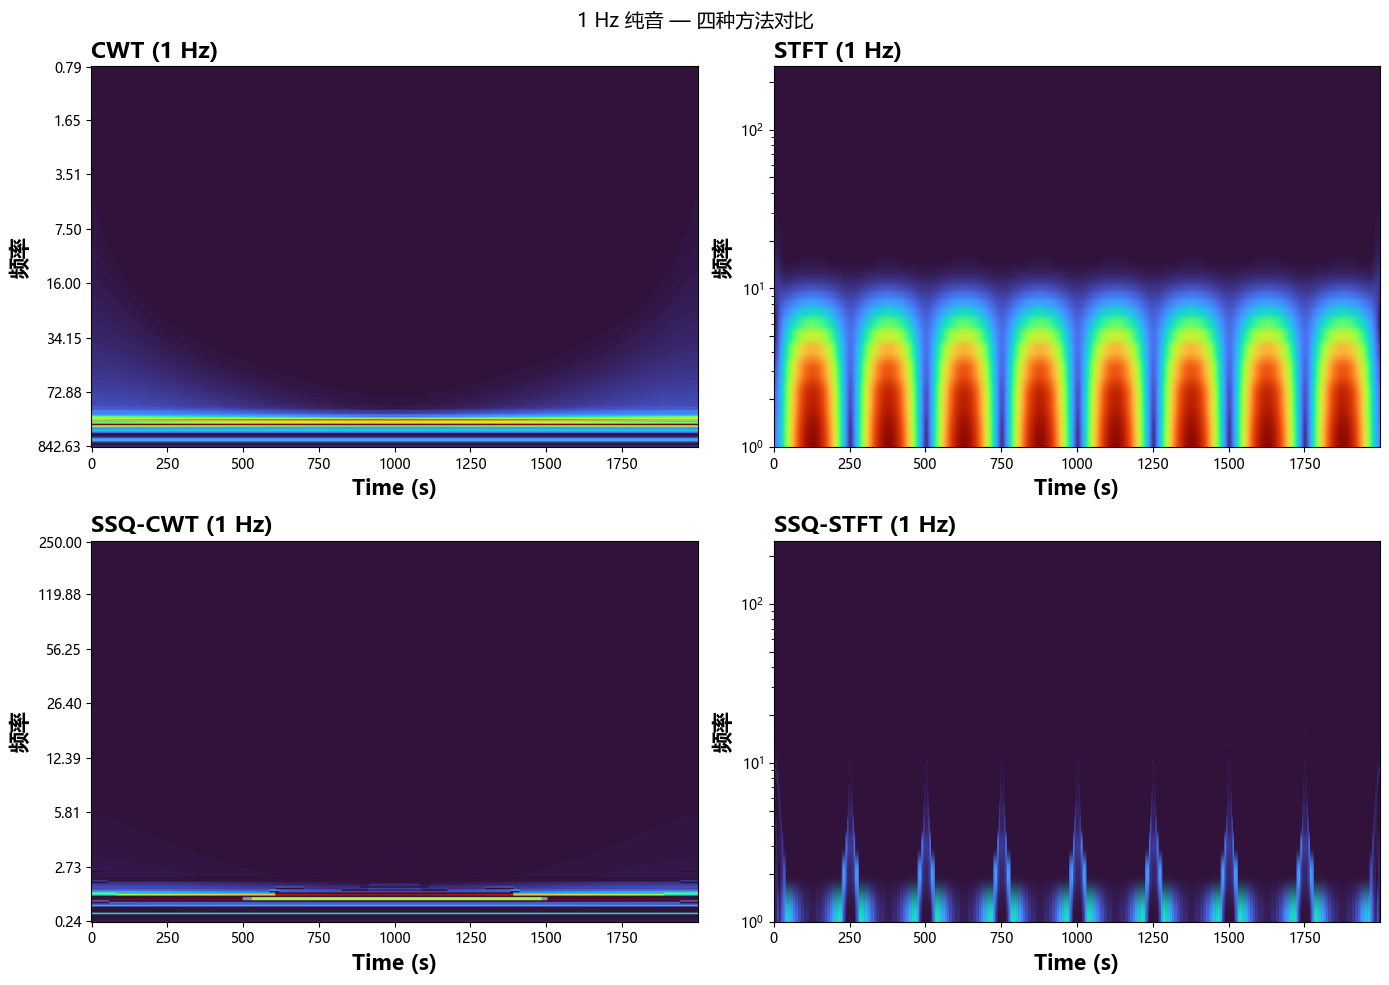

In [25]:
# 生成 1 Hz 纯音
t1 = np.linspace(0, T, int(sr * T), endpoint=False)
x1 = np.sin(2 * np.pi * 1 * t1)  # 1 Hz

# ---- CWT ----
Wx1, scales1 = cwt(x1, fs=sr)

# ---- STFT ----
Sx1 = stft(x1, fs=sr)
freqs1 = np.linspace(0, sr / 2, Sx1.shape[0])

# ---- SSQ-CWT ----
Tx1, _, fs_cwt1, _ = ssq_cwt(x1, fs=sr)

# ---- SSQ-STFT ----
Tx1_stft, _, fs_stft1, _ = ssq_stft(x1, fs=sr)

# ---- 四图对比 ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

imshow(Wx1, yticks=scales1, abs=1, ax=axes[0, 0], show=0,
       title="CWT (1 Hz)", xlabel="Time (s)", ylabel="频率")

imshow(Sx1, yticks=freqs1, abs=1, ax=axes[0, 1], show=0, origin='lower',
       title="STFT (1 Hz)", xlabel="Time (s)", ylabel="频率")
axes[0, 1].set_yscale('log')
axes[0, 1].set_ylim(1, sr / 2)
axes[0, 1].set_yticks([1, 2, 5, 10, 20, 50, 100, 200])

imshow(Tx1, yticks=fs_cwt1, abs=1, ax=axes[1, 0], show=0,
       title="SSQ-CWT (1 Hz)", xlabel="Time (s)", ylabel="频率")

imshow(Tx1_stft, yticks=fs_stft1, abs=1, ax=axes[1, 1], show=0, origin='lower',
       title="SSQ-STFT (1 Hz)", xlabel="Time (s)", ylabel="频率")
axes[1, 1].set_yscale('log')
axes[1, 1].set_ylim(1, sr / 2)
axes[1, 1].set_yticks([1, 2, 5, 10, 20, 50, 100, 200])

plt.suptitle("1 Hz 纯音 — 四种方法对比", fontsize=14)
plt.tight_layout()
plt.show()